# INCOME PREDICTION — CENSUS DATA
# Binary Classification using Machine Learning

## 1. Problem Understanding

### Business Problem
The goal is to predict whether a person earns more than $50K/year
based on demographic and employment data from the US Census.

This prediction helps:
- Banks identify high-income customers for premium products
- Government agencies for tax planning and policy decisions
- HR teams for salary benchmarking

### ML Formulation
- Type          : Binary Classification
- Target        : income (<=50K or >50K)
- Positive class: >50K (minority — 24.1%)
- Negative class: <=50K (majority — 75.9%)
- Train/Test    : 80/20 stratified split

### Why ROC-AUC as primary metric?
Accuracy is misleading for imbalanced data.
A model predicting everyone as <=50K gets 75% accuracy trivially.
ROC-AUC measures discrimination ability regardless of threshold.

### Cost of Errors
- False Positive (predict >50K, actually <=50K)
  → Minor issue — person gets unnecessary offer
- False Negative (predict <=50K, actually >50K)
  → Bigger issue — miss a high-value customer

### Target
- ROC-AUC > 0.90 = success
- ROC-AUC > 0.92 = excellent

In [1]:

# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Model Saving
import joblib

## 2. Data Understanding & EDA

In this section we:
- Load and inspect the dataset
- Understand distributions of features
- Check class imbalance
- Detect missing values and outliers
- Understand relationships between features and target

In [2]:
df = pd.read_csv('adult.csv',)
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape : 32,561 rows × 15 columns


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


The dataset contains 32,561 records, which is sufficiently large for building a reliable machine learning model.
With 15 features, the dataset has a balanced complexity (not too small, not too high-dimensional).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


“Although the dataset shows no missing values, I identified that missing values are encoded as ‘?’. The dataset contains both numerical and categorical features, requiring preprocessing. I also identified redundant and irrelevant features like education.num and fnlwgt.

In [4]:
df.columns = (df.columns.str.strip()
    .str.replace('.', '_')
    .str.replace(' ', '_')
    .str.title())
print(df.columns.tolist())

['Age', 'Workclass', 'Fnlwgt', 'Education', 'Education_Num', 'Marital_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital_Gain', 'Capital_Loss', 'Hours_Per_Week', 'Native_Country', 'Income']


In [5]:
df = df.rename(columns={
    'Workclass': 'Employment_Type',
    'Fnlwgt': 'Final_Weight',
    'Education': 'Education_Level',
    'Education_Num': 'Education_Years',
    'Occupation': 'Job_Role',
    'Sex': 'Gender',
    'Hours_Per_Week': 'Weekly_Work_Hours',
    'Native_Country': 'Country'})
print(df.columns.tolist())

['Age', 'Employment_Type', 'Final_Weight', 'Education_Level', 'Education_Years', 'Marital_Status', 'Job_Role', 'Relationship', 'Race', 'Gender', 'Capital_Gain', 'Capital_Loss', 'Weekly_Work_Hours', 'Country', 'Income']


I standardized column names by removing special characters and converting them into a consistent format, then renamed key features for better readability and business understanding.”

In [6]:
df.describe().round(2)

,Age,Final_Weight,Education_Years,Capital_Gain,Capital_Loss,Weekly_Work_Hours
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


**Numerical Data Insights**
- Age distribution shows a working population with a wide range (17–90), centered around middle age (~38), indicating a realistic workforce dataset.

- Final_Weight has extremely high variance and represents census sampling weight rather than a meaningful feature, so it was removed from the analysis.

- Education_Years is centered around 10 years (high school level), indicating that most individuals have moderate education, with fewer highly educated individuals.

- Capital_Gain is highly skewed, with most values being 0 and a few very large values (up to 99999), making it a strong indicator of high income.

- Capital_Loss follows a similar pattern to capital gain, with mostly zero values and a few extreme cases, but has relatively lower impact.

- Weekly_Work_Hours is concentrated around 40 hours per week, indicating standard full-time employment, with a few extreme values acting as outliers.

- Both Capital_Gain and Capital_Loss are zero-inflated features, meaning a large portion of the data contains zeros.

- Due to heavy skewness in financial features, log transformation was applied to reduce skewness and improve model performance.

- Binary features such as Has_Capital_Gain and Has_Capital_Loss were created to capture whether a person has any financial activity.

- Outliers are present in features like Capital_Gain and Weekly_Work_Hours, which were handled using robust scaling techniques.

- Overall, the dataset contains a mix of well-distributed features (Age, Education, Hours) and highly skewed features (Capital Gain/Loss), requiring different preprocessing strategies.The 'Final_Weight' column is not useful for prediction as it represents census sampling weight. It will be removed during preprocessing.

In [7]:
df.replace('?', np.nan, inplace=True)
missing = df.isnull().sum()
print(" Missing Values per Column:\n")
print(missing[missing > 0])
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage:\n")
print(missing_pct[missing_pct > 0].round(2))

 Missing Values per Column:

Employment_Type    1836
Job_Role           1843
Country             583
dtype: int64

Missing Percentage:

Employment_Type    5.64
Job_Role           5.66
Country            1.79
dtype: float64


- Missing values were identified in Employment_Type, Job_Role, and Country columns. 
Since the percentage of missing values is low, imputation using the most frequent value will be applied in preprocessing.

**Target Variable Analysis (VERY IMPORTANT)**

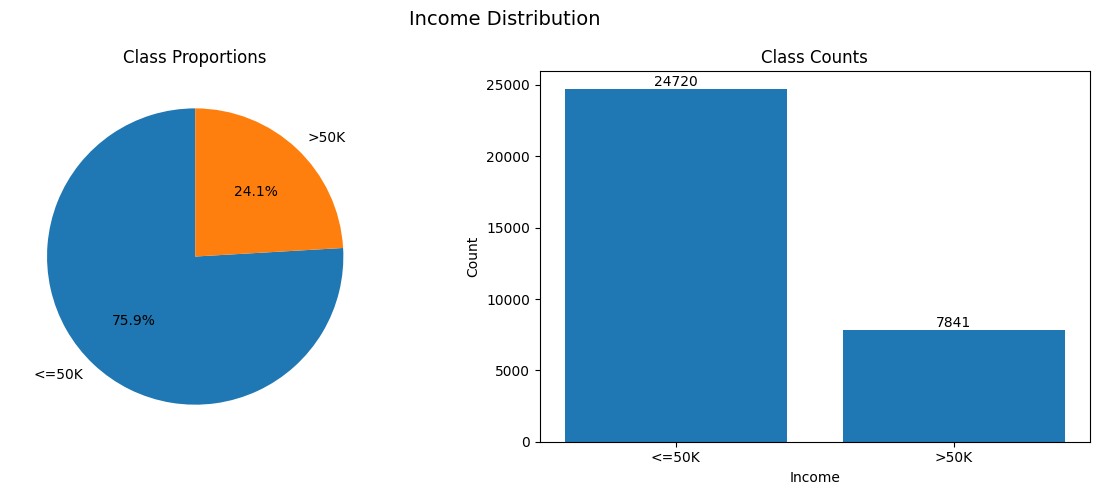

Class imbalance ratio: 3.15:1


In [8]:
counts = df['Income'].value_counts()
counts = counts.sort_index()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].pie(counts.values,labels=counts.index,autopct='%1.1f%%',startangle=90)
ax[0].set_title("Class Proportions")
bars = ax[1].bar(counts.index, counts.values)
ax[1].set_title("Class Counts")
ax[1].set_xlabel("Income")
ax[1].set_ylabel("Count")
for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2,height,f'{int(height)}',ha='center',va='bottom')
plt.suptitle("Income Distribution", fontsize=14)
plt.tight_layout()
plt.show()
majority = counts.max()
minority = counts.min()
ratio = majority / minority
print(f"Class imbalance ratio: {ratio:.2f}:1")

- The dataset is imbalanced, with approximately 75.9% of individuals earning <=50K and only 24.1% earning >50K.

- The class imbalance ratio is around 3.15:1, indicating that the majority class dominates the dataset.

- This imbalance can lead to biased model predictions towards the <=50K class if not handled properly.

- Accuracy alone is not a reliable metric for this dataset due to class imbalance.

- Evaluation metrics such as F1-score, Precision, Recall, and ROC-AUC are more appropriate for model evaluation.

- There is a higher risk of the model predicting most samples as <=50K to achieve high accuracy.

- Special techniques are required to handle imbalance, such as:

           i.Using class weights (e.g., 'balanced').
      
          ii.Using scale_pos_weight (for XGBoost).
    
          iii.Applying threshold tuning.

- The minority class (>50K) is more important to detect correctly in many real-world scenarios (e.g., targeting high-income individuals).

- The dataset still has a reasonable number of minority samples (~7800), so resampling techniques are not strictly necessary.

- Overall, the imbalance is moderate (not extreme), and can be effectively handled using model-based techniques.

**Numerical Features Analysis**

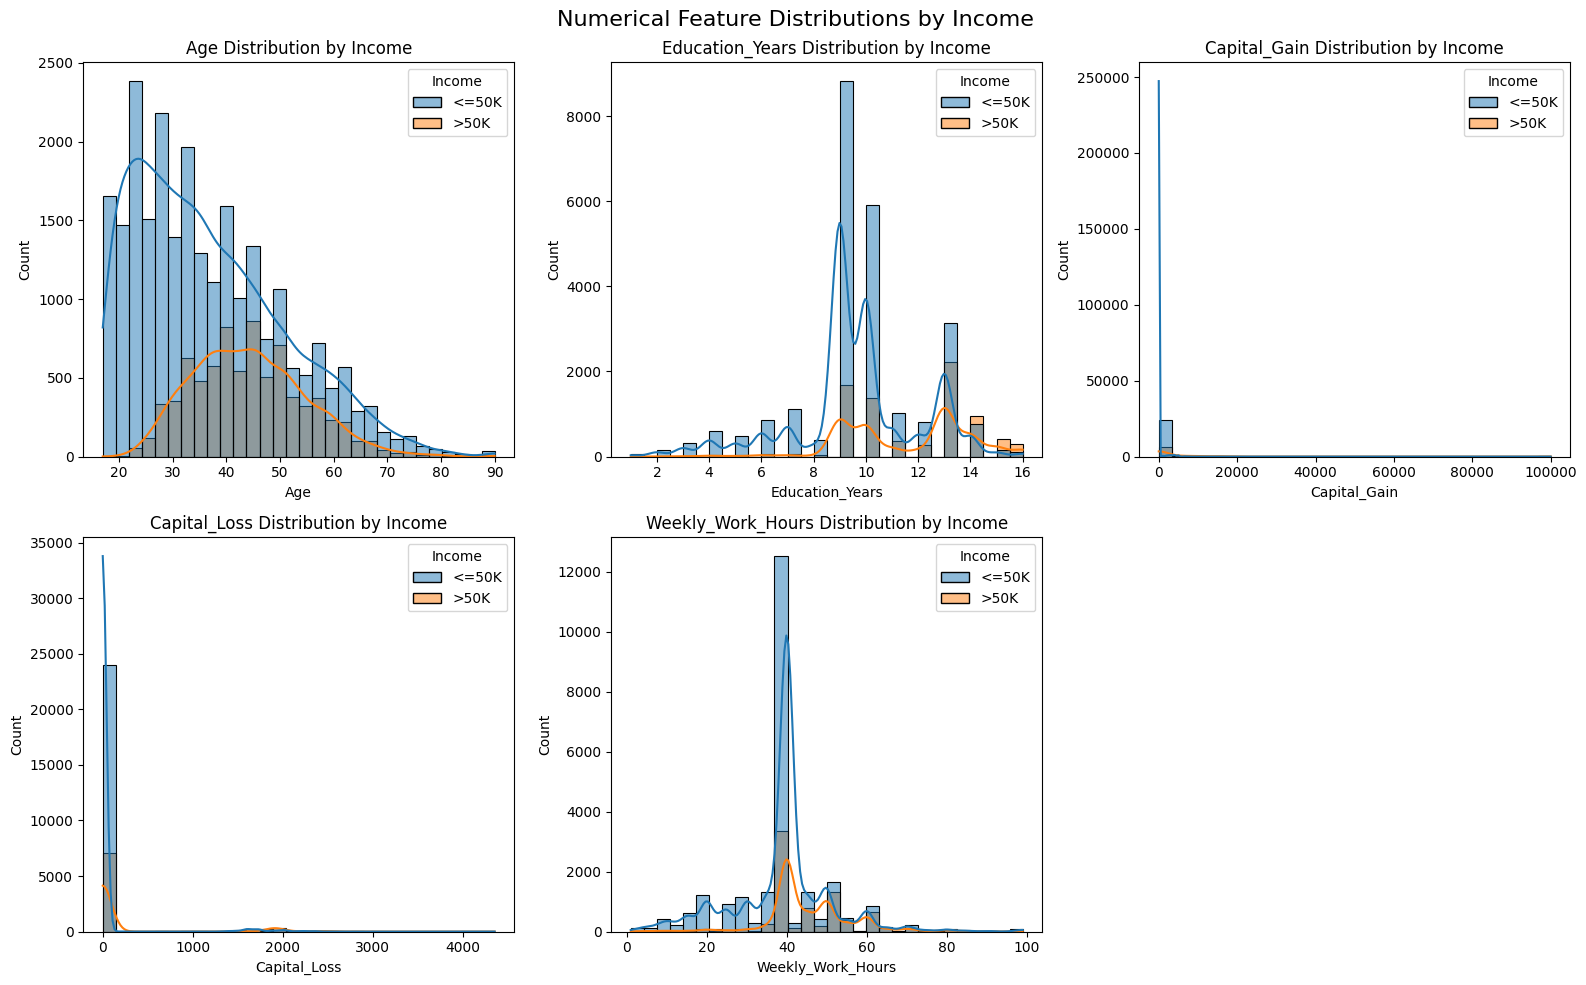

In [9]:
num_cols = ['Age', 'Education_Years', 'Capital_Gain','Capital_Loss', 'Weekly_Work_Hours']
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)    
    sns.histplot(data=df,x=col,hue='Income',bins=30,kde=True)    
    plt.title(f"{col} Distribution by Income")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.suptitle("Numerical Feature Distributions by Income", fontsize=16)
plt.tight_layout()
plt.show()

- People earning more than 50K are usually older. Income tends to increase with age up to middle age.

- Most low-income individuals (<=50K) are younger (around 20–40 years), while high-income individuals are mostly between 35–60 years.

- People with more years of education (12–16 years) are more likely to earn above 50K.

- Lower education levels are mostly linked to income below 50K, showing that education plays an important role.

- Capital Gain has many zero values, but if someone has even a small capital gain, they are more likely to earn above 50K.

- Capital Loss shows a similar pattern, but it is not as strong as capital gain.

- Most people work around 40 hours per week, but those who work more hours (45–60) have a slightly higher chance of earning above 50K.

- There is overlap between low and high income groups in most features, so one feature alone cannot clearly separate them.

- Capital Gain is the most important feature, as even small values strongly indicate higher income.

- Overall, Age, Education, Working Hours, and Capital Gain are key factors that help predict income.

**Categorical Features Analysis**

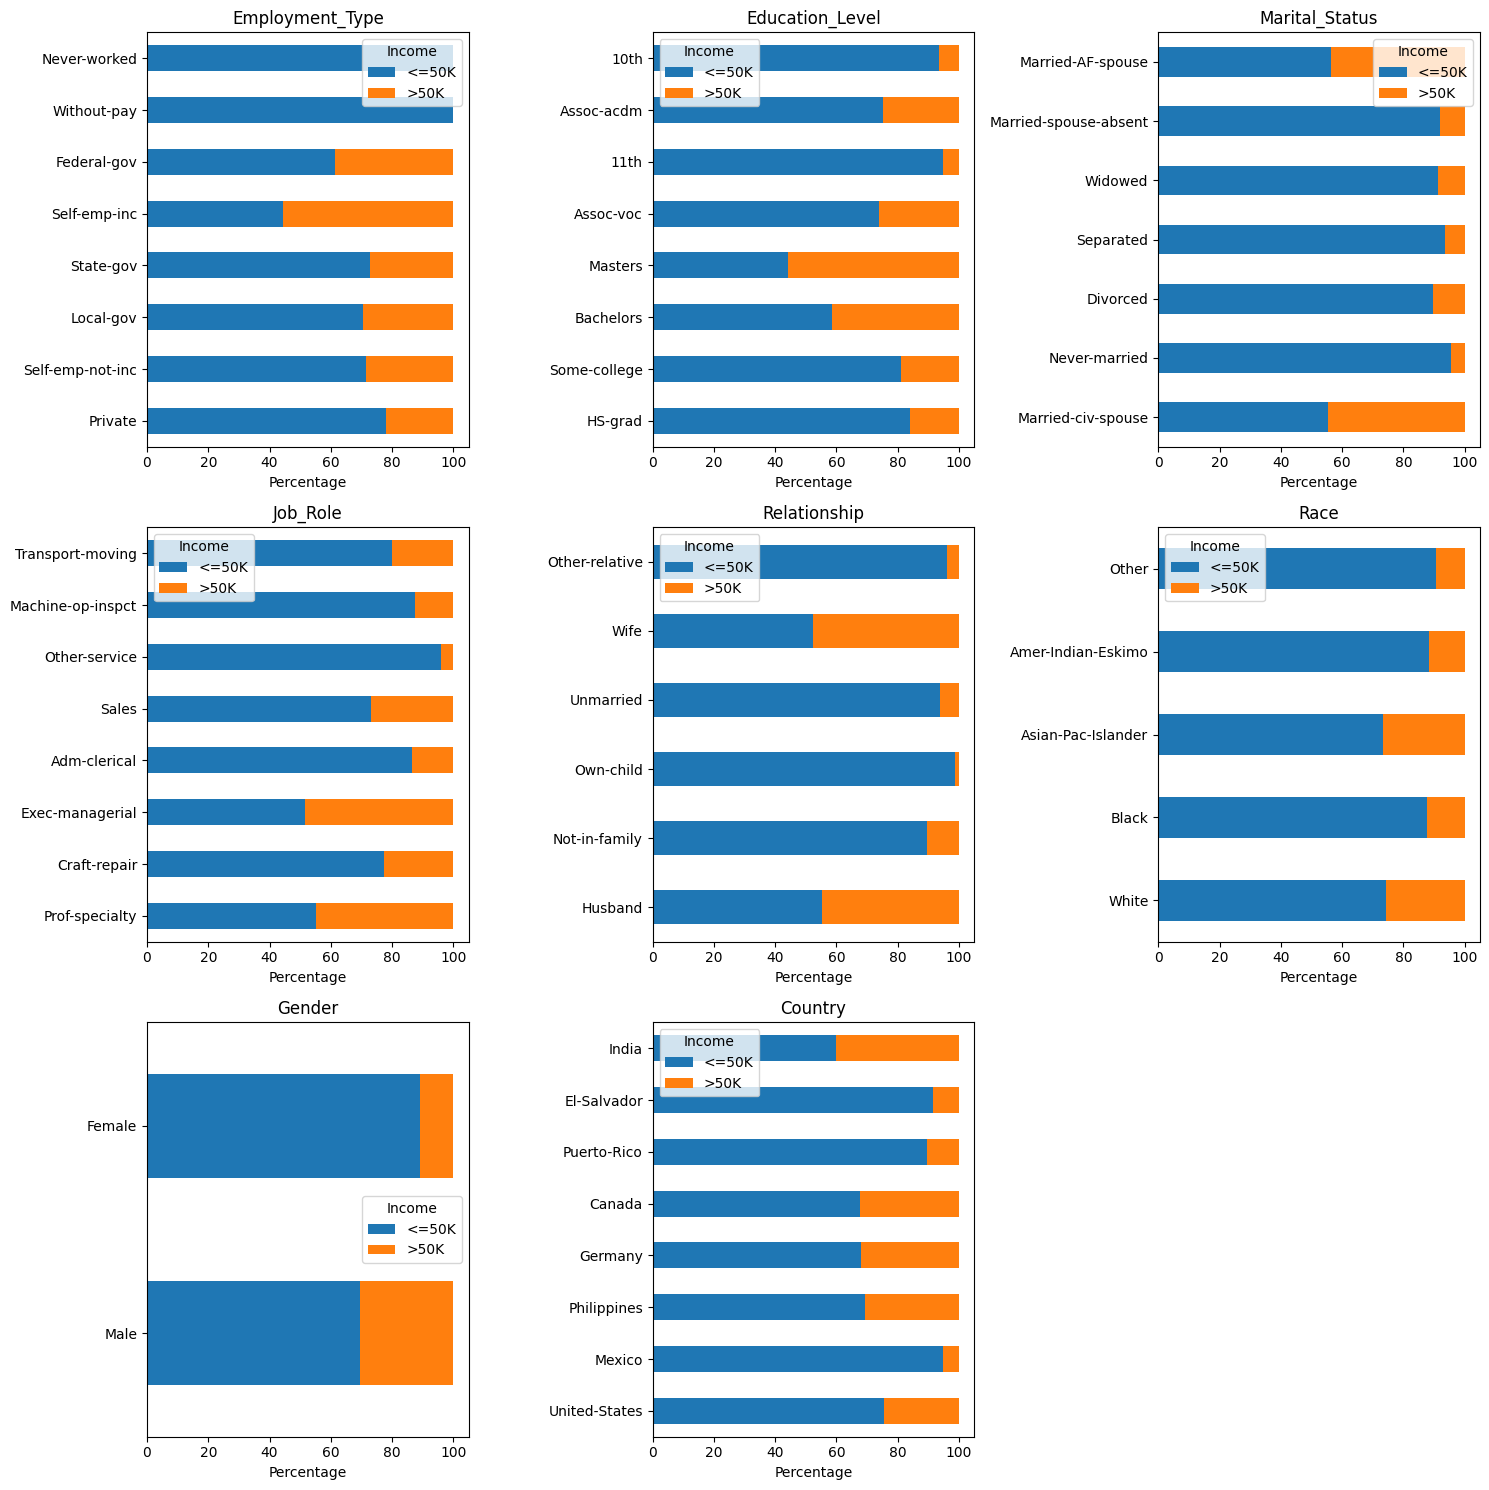

In [10]:
cat_cols_plot = [
    'Employment_Type', 'Education_Level', 'Marital_Status',
    'Job_Role', 'Relationship', 'Race', 'Gender', 'Country']
n_cols = 3
n_rows = (len(cat_cols_plot) // 3) + 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cat_cols_plot):    
    ct = pd.crosstab(df[col], df['Income'], normalize='index') * 100
    top = df[col].value_counts().head(8).index
    ct = ct.loc[top]    
    ct.plot(kind='barh', stacked=True, ax=axes[i])    
    axes[i].set_title(col)
    axes[i].set_xlabel("Percentage")
    axes[i].set_ylabel("")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

- Employment_Type shows that people working in private and self-employed jobs have a higher chance of earning >50K compared to government or unpaid work.

- Education_Level confirms that higher education (Bachelors, Masters) is strongly linked with higher income, while lower education levels mostly fall under <=50K.

- Marital_Status shows that married individuals (especially married-civ-spouse) are more likely to earn >50K, while never-married individuals mostly earn <=50K.

- Job_Role indicates that managerial and professional jobs (Exec-managerial, Prof-specialty) have a higher proportion of >50K income.

- Jobs like service, cleaning, and machine operations are mostly associated with <=50K income.

- Relationship shows that husbands are more likely to earn >50K, while own-child and unmarried individuals mostly fall under <=50K.

- Gender shows a noticeable difference, where males have a higher proportion of >50K income compared to females.

- Race does not show a strong separation between income groups, meaning it has weaker predictive power.

- Country also does not show strong variation, as most countries have similar income distributions.

- Overall, Education_Level, Job_Role, and Marital_Status are the strongest categorical features influencing income.

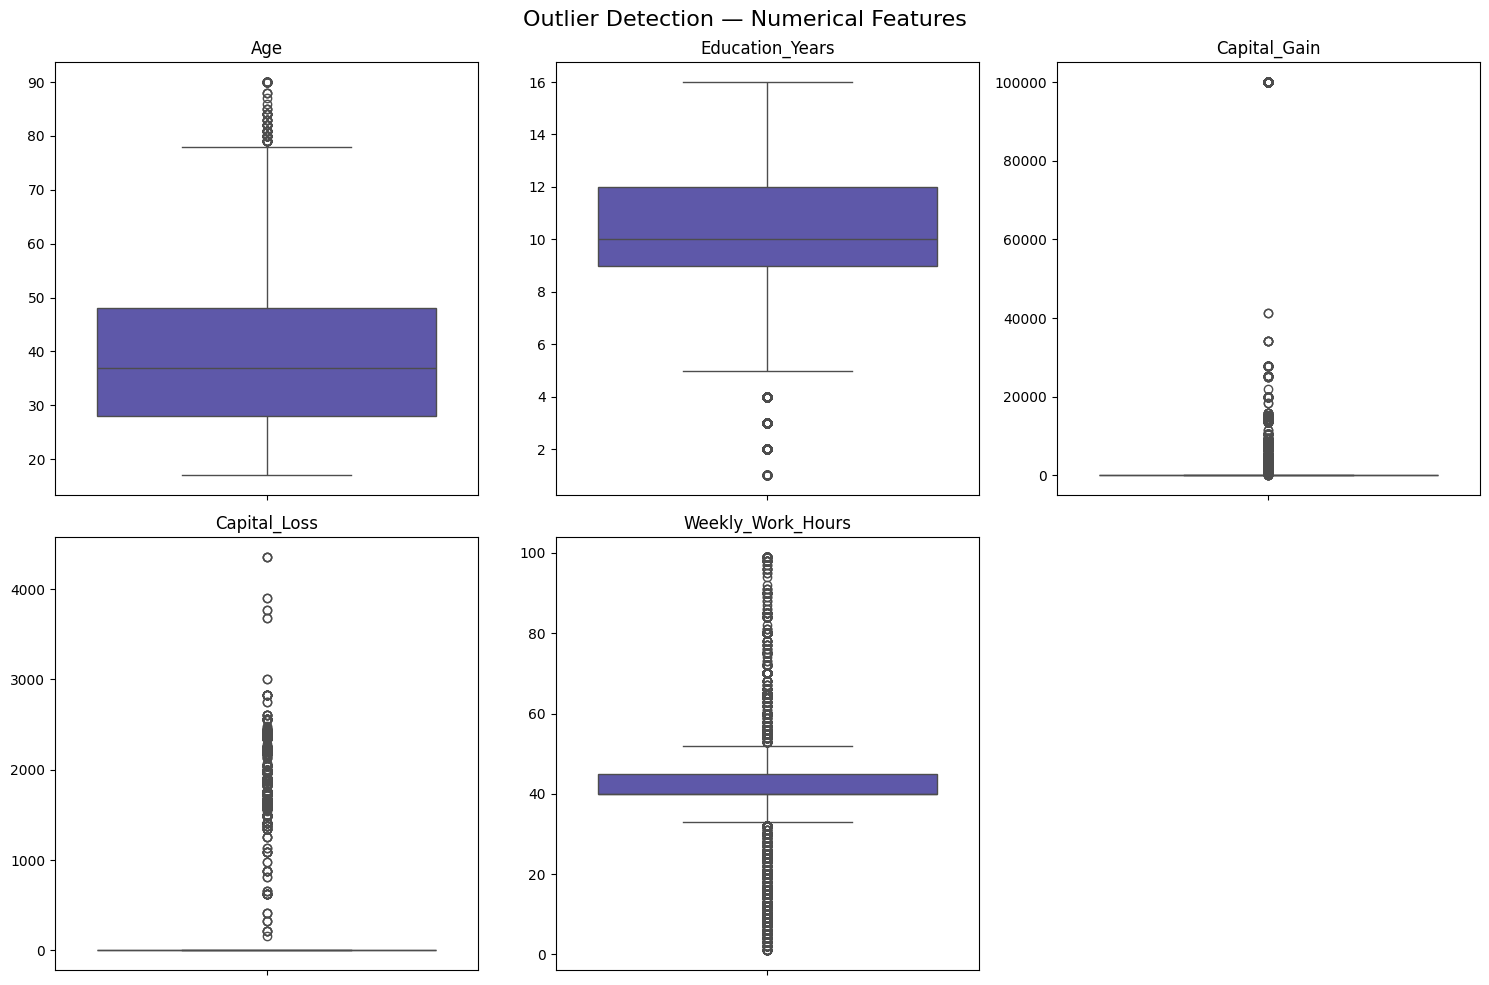

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = [
    'Age', 'Education_Years', 'Capital_Gain',
    'Capital_Loss', 'Weekly_Work_Hours']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)    
    sns.boxplot(y=df[col], color='#534AB7')
    plt.title(col)
    plt.ylabel("")
plt.suptitle("Outlier Detection — Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

- I observed some high values in Age, but these represent real older people, so I decided not to remove them.

- In Education_Years, there are a few low values, but they are valid and meaningful.

- Capital_Gain has many extreme values and is highly skewed, but these values are important for identifying high-income individuals.

- Capital_Loss shows a similar pattern to capital gain, with many extreme values.

- Weekly_Work_Hours has some very high and very low values, but these represent real working conditions like overtime or part-time jobs.

- Overall, I understood that these outliers are not errors but real-world data.
  So, I decided not to remove them and instead handled them using transformation and scaling.

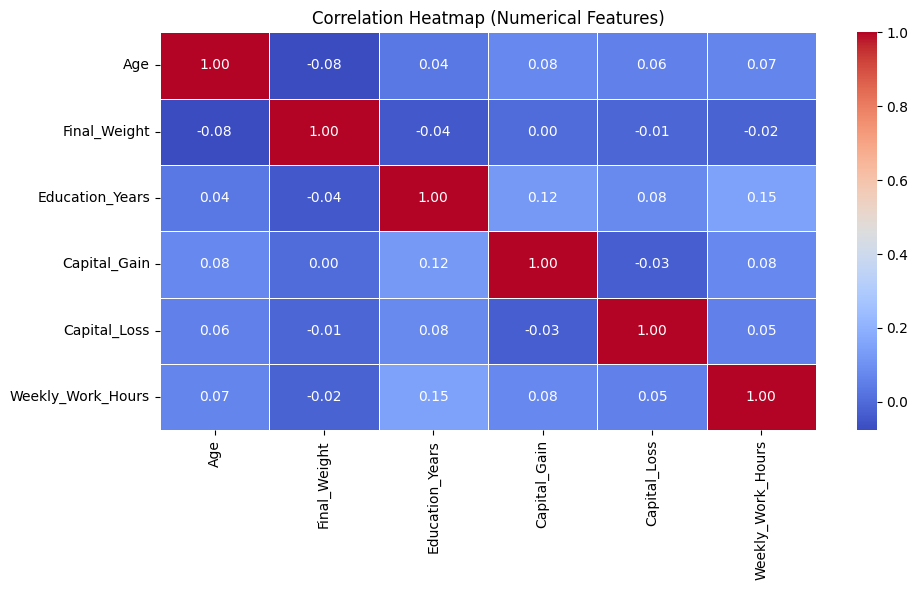

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

- Most numerical features show very low correlation with each other, indicating minimal multicollinearity in the dataset.

- Age has very weak correlation with other features, suggesting it provides independent information.

- Education_Years has a slight positive correlation with Weekly_Work_Hours (0.15), indicating that more educated individuals may work slightly longer hours.

- Capital_Gain shows very weak correlation with all other features, meaning it captures unique information and is an important independent predictor.

- Capital_Loss also has very low correlation with other features, similar to capital gain.

- Final_Weight shows almost no correlation with any feature, reinforcing that it is not useful for prediction.

- Overall, no strong linear relationships exist between numerical features, which is beneficial for model performance.

## 3. Data Preprocessing

- Handled missing values in categorical features (Employment_Type, Job_Role, Country) using mode imputation.

- Converted categorical variables into numerical format using encoding techniques.

- Applied log transformation to skewed features like Capital_Gain and Capital_Loss.

- Created new features such as Has_Capital_Gain and Has_Capital_Loss.

- Scaled numerical features using StandardScaler and RobustScaler to handle different distributions and outliers.

- Split the data into training and testing sets for model building.

 **Identifying and Removing Duplicate Records**

In [13]:
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed successfully.")
else:
    print("No duplicates found.")
print(f"Final shape: {df.shape}")

Duplicates found: 24
Duplicates removed successfully.
Final shape: (32537, 15)


- A total of 24 duplicate records were identified in the dataset.
- These duplicates were removed to ensure data quality and avoid bias.
- After removal, the dataset contains 32,537 unique records and 15 features.

**Handling Skewed Numerical Features (Log Transformation)**

Skewness was checked for numerical features to identify highly skewed distributions. 
Features with skewness greater than 1 were selected for log transformation to reduce skewness 
and improve model performance.

In [14]:
num_cols = ['Age', 'Education_Years', 'Capital_Gain', 'Capital_Loss', 'Weekly_Work_Hours']
skew_before = df[num_cols].skew()
print("Skewness BEFORE:\n", skew_before.round(3))
TRANSFORM_COLS = [col for col in num_cols
                  if abs(skew_before[col]) > 1 and (df[col] >= 0).all()]
print("\nColumns selected for log transform:", TRANSFORM_COLS)
df_transformed = df.copy()
for col in TRANSFORM_COLS:
    df_transformed[col] = np.log1p(df_transformed[col])
skew_after = df_transformed[num_cols].skew()
print("\nSkewness AFTER:\n", skew_after.round(3))
comparison = pd.DataFrame({
    'Before': skew_before,
    'After': skew_after})
comparison['Improved'] = abs(comparison['After']) < abs(comparison['Before'])
print("\nSkewness Comparison:")
display(comparison.round(3))

Skewness BEFORE:
 Age                   0.558
Education_Years      -0.310
Capital_Gain         11.949
Capital_Loss          4.593
Weekly_Work_Hours     0.229
dtype: float64

Columns selected for log transform: ['Capital_Gain', 'Capital_Loss']

Skewness AFTER:
 Age                  0.558
Education_Years     -0.310
Capital_Gain         3.095
Capital_Loss         4.306
Weekly_Work_Hours    0.229
dtype: float64

Skewness Comparison:


,Before,After,Improved
Age,0.558,0.558,False
Education_Years,-0.310,-0.310,False
Capital_Gain,11.949,3.095,True
Capital_Loss,4.593,4.306,True
Weekly_Work_Hours,0.229,0.229,False


- Age shows low skewness (0.558), so no transformation is required.

- Education_Years has slight negative skew (-0.310), which is within acceptable range and does not require transformation.

- Capital_Gain is highly skewed (11.949), and after log transformation, it reduced significantly to 3.095, showing clear improvement.

- Capital_Loss is also highly skewed (4.593), and log transformation slightly reduced it to 4.306, but it still remains skewed.

- Weekly_Work_Hours has very low skewness (0.229), so no transformation is needed.

**Applied log transformation:**
- Capital_Gain  
- Capital_Loss  


In [15]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(df[['Gender']].head())

   Gender
0       0
1       0
2       0
3       0
4       0


# 4.Feature Engineering

To enhance model performance, additional features were engineered based on domain understanding and data distribution.

In [16]:
education_group = {
    'Preschool': 'Primary',
    '1st-4th': 'Primary',
    '5th-6th': 'Primary',
    '7th-8th': 'Middle',
    '9th': 'Secondary',
    '10th': 'Secondary',
    '11th': 'Secondary',
    '12th': 'Secondary',
    'HS-grad': 'High_School',
    'Some-college': 'College',
    'Assoc-voc': 'College',
    'Assoc-acdm': 'College',
    'Bachelors': 'Undergraduate',
    'Masters': 'Postgraduate',
    'Prof-school': 'Professional',
    'Doctorate': 'Doctorate'
}
df['Education_Group'] = df['Education_Level'].map(education_group)

In [17]:
df = df.drop(columns=['Education_Level'], errors='ignore')

Education_Level was grouped into meaningful categories to reduce complexity. 
The original column was removed as its information is already captured in 
Education_Years and the newly created Education_Group feature.

**multicollinearity handling**

In [18]:
import numpy as np
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Income', errors='ignore')
corr = df[num_cols].corr()
threshold = 0.8
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            val = corr.iloc[i, j]
            high_corr.append((col1, col2, val))
if high_corr:
    print("Highly correlated pairs:\n")
    for c1, c2, v in high_corr:
        print(f"{c1} ↔ {c2}  (corr = {v:.2f})")
else:
    print("No high correlation found")

No high correlation found


In [19]:
df = df.drop(columns=['Final_Weight'], errors='ignore')

All relevant features were retained to preserve data integrity. 
The 'Final_Weight' column was removed as it represents sampling weight and does not contribute to prediction. 
Duplicate removal was performed only on the original dataset to avoid losing valid observations created after feature reduction.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                32537 non-null  int64 
 1   Employment_Type    30701 non-null  object
 2   Education_Years    32537 non-null  int64 
 3   Marital_Status     32537 non-null  object
 4   Job_Role           30694 non-null  object
 5   Relationship       32537 non-null  object
 6   Race               32537 non-null  object
 7   Gender             32537 non-null  int64 
 8   Capital_Gain       32537 non-null  int64 
 9   Capital_Loss       32537 non-null  int64 
 10  Weekly_Work_Hours  32537 non-null  int64 
 11  Country            31955 non-null  object
 12  Income             32537 non-null  object
 13  Education_Group    32537 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


**Train-Test Split**

The dataset was split into training and testing sets to evaluate model performance on unseen data.

- 80% of the data was used for training and 20% for testing
- Stratification was applied on the target variable to maintain class distribution in both sets
- A fixed random state (42) was used to ensure reproducibility

In [21]:
from sklearn.model_selection import train_test_split
X = df.drop('Income', axis=1)
y = df['Income']
print("X shape:", X.shape)
print("y shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest distribution:\n", y_test.value_counts(normalize=True).round(3))

X shape: (32537, 13)
y shape: (32537,)

Train shape: (26029, 13)
Test shape : (6508, 13)

Train distribution:
 Income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64

Test distribution:
 Income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


The dataset was split into training and testing sets using an 80-20 ratio. Stratification ensured that the class distribution remained consistent across both sets. The dataset is slightly imbalanced, with approximately 76% of instances belonging to the <=50K class and 24% to the >50K class.

In [22]:
TRANSFORM_COLS = ['Capital_Gain', 'Capital_Loss']
for col in ['Capital_Gain', 'Capital_Loss']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])
print("Skewness AFTER transformation (Train):\n")
print(X_train[TRANSFORM_COLS].skew().round(3))

Skewness AFTER transformation (Train):

Capital_Gain    3.083
Capital_Loss    4.272
dtype: float64


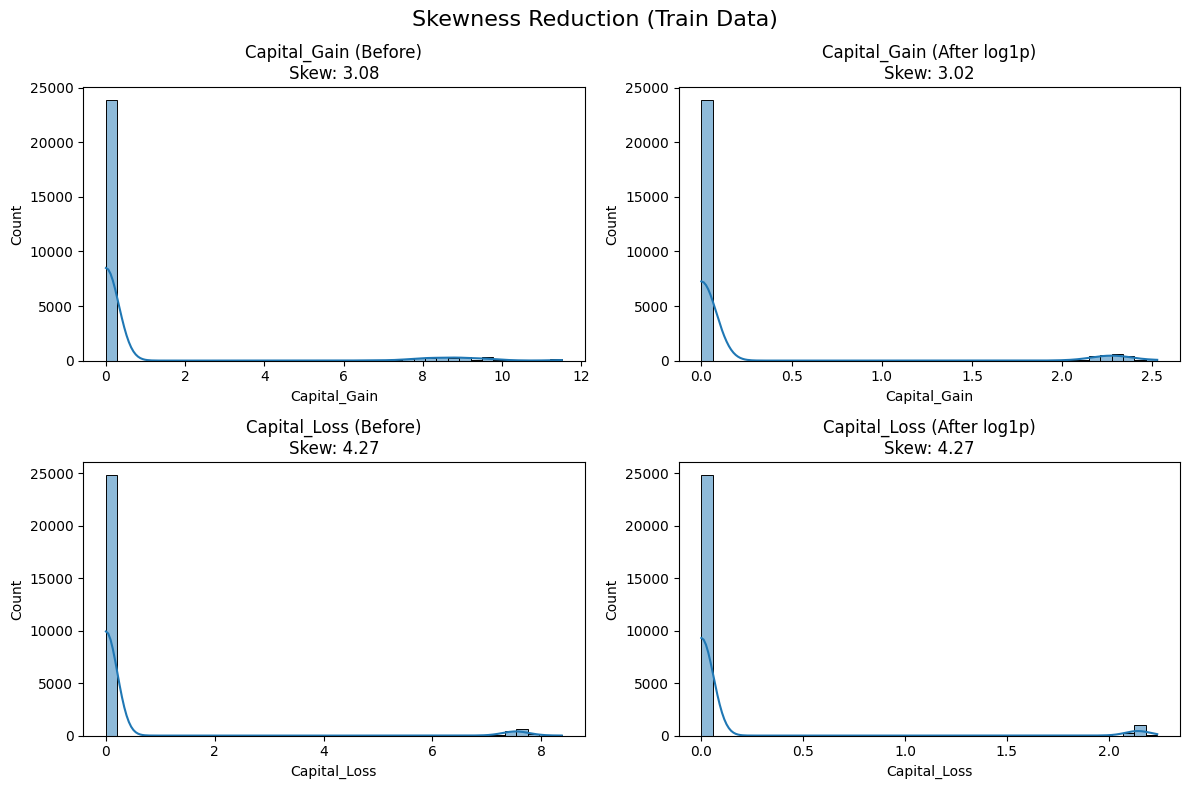

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cols = ['Capital_Gain', 'Capital_Loss']
X_train_before = X_train.copy()
X_train_after = X_train.copy()
for col in cols:
    X_train_after[col] = np.log1p(X_train_before[col])
fig, axes = plt.subplots(len(cols), 2, figsize=(12, 8))
for i, col in enumerate(cols):
    sns.histplot(X_train_before[col],bins=40,kde=True,ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (Before)\nSkew: {X_train_before[col].skew():.2f}")
    sns.histplot(X_train_after[col],bins=40,kde=True,ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} (After log1p)\nSkew: {X_train_after[col].skew():.2f}")
plt.suptitle("Skewness Reduction (Train Data)", fontsize=16)
plt.tight_layout()
plt.show()

**Preprocessing Pipeline — ColumnTransformer**

Different columns require different preprocessing techniques based on their nature:

| Column Group    | Columns                                             | Treatment          | Why                              |
|-----------------|-----------------------------------------------------|--------------------|----------------------------------|
| NUM_STD_COLS    | Age, Education_Years, Weekly_Work_Hours             | StandardScaler     | Features with moderate scale     |
| NUM_ROBUST_COLS | Capital_Gain, Capital_Loss                          | RobustScaler       | Handles skewness & outliers      |
| BIN_COLS        | Gender                                              | Passthrough        | Already binary (0/1)             |
| CAT_COLS        | Employment_Type, Marital_Status, Job_Role,          | OneHotEncoder      | No inherent order                |
|                 | Relationship, Race, Country, Education_Group        |                    |                                  |

In [24]:
NUM_STD_COLS = ['Age', 'Education_Years', 'Weekly_Work_Hours']
NUM_ROBUST_COLS = ['Capital_Gain', 'Capital_Loss']
BIN_COLS = ['Gender']

CAT_COLS = [
    'Employment_Type', 'Marital_Status', 'Job_Role',
    'Relationship', 'Race', 'Country', 'Education_Group'
]
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
num_std_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])
num_robust_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False  ))])
preprocessor = ColumnTransformer([
    ('num_std', num_std_pipeline, NUM_STD_COLS),
    ('num_robust', num_robust_pipeline, NUM_ROBUST_COLS),
    ('bin', 'passthrough', BIN_COLS),
    ('cat', cat_pipeline, CAT_COLS)])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)
print("Train shape:", X_train_processed.shape)
print("Test shape :", X_test_processed.shape)

Train shape: (26029, 88)
Test shape : (6508, 88)


After applying OneHotEncoding to categorical features, the number of features increased to 88. This is expected as each category is converted into a separate feature, allowing the model to capture detailed patterns.

In [25]:
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
ohe_features = ohe.get_feature_names_out(CAT_COLS)
print("\nFeature Breakdown:")
print("StandardScaler :", len(NUM_STD_COLS))
print("RobustScaler   :", len(NUM_ROBUST_COLS))
print("Binary         :", len(BIN_COLS))
print("OneHotEncoded  :", len(ohe_features))
total = (
    len(NUM_STD_COLS) +
    len(NUM_ROBUST_COLS) +
    len(BIN_COLS) +
    len(ohe_features))
print("Total Features :", total)


Feature Breakdown:
StandardScaler : 3
RobustScaler   : 2
Binary         : 1
OneHotEncoded  : 82
Total Features : 88


After preprocessing, the dataset expanded to 88 features. Most features were generated through OneHotEncoding of categorical variables, while numerical and binary features remained limited. This ensures a rich representation of categorical information for model learning.

# 5. Model Selection
Why these 4 models?
- Logistic Regression : linear baseline, fast, interpretable
- Random Forest       : tree ensemble, handles mixed features
- XGBoost             : gradient boosting, strong performance on tabular data
- LightGBM            : faster boosting model, efficient on large datasets

Class imbalance was handled using:
- class_weight='balanced' for Logistic Regression and Random Forest
- scale_pos_weight for XGBoost and LightGBM

In [26]:
y_train_enc = y_train.map({'<=50K': 0, '>50K': 1})
y_test_enc  = y_test.map({'<=50K': 0, '>50K': 1})

In [27]:
scale_pos_weight = (y_train_enc == 0).sum() / (y_train_enc == 1).sum()
models = {"Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced',
                                                    solver='liblinear',random_state=42),
          "Random Forest": RandomForestClassifier(n_estimators=200,max_depth=10,
                                                  class_weight='balanced',random_state=42,
                                                  n_jobs=-1),
          "XGBoost": XGBClassifier(
              n_estimators=200,learning_rate=0.1,max_depth=6,scale_pos_weight=scale_pos_weight,
              eval_metric='logloss',random_state=42,n_jobs=-1),
         "LightGBM": LGBMClassifier(n_estimators=200,learning_rate=0.1,num_leaves=31,
                                    scale_pos_weight=scale_pos_weight,random_state=42,n_jobs=-1,
        verbose=-1)}

# 6. Model Training & Tuning   


In [28]:
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train_enc)
    
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    acc  = accuracy_score(y_test_enc, y_pred)
    f1   = f1_score(y_test_enc, y_pred)
    roc  = roc_auc_score(y_test_enc, y_proba)
    prec = precision_score(y_test_enc, y_pred)
    rec  = recall_score(y_test_enc, y_pred)
    
    results.append([name, acc, f1, roc, prec, rec])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "F1 Score", "ROC-AUC", "Precision", "Recall"
])

results_df.sort_values(by="F1 Score", ascending=False).round(4)

,Model,Accuracy,F1 Score,ROC-AUC,Precision,Recall
2,XGBoost,0.8328,0.7088,0.9225,0.6107,0.8444
3,LightGBM,0.8308,0.7038,0.9212,0.6087,0.8342
0,Logistic Regression,0.8002,0.6656,0.8944,0.5578,0.8253
1,Random Forest,0.7892,0.6647,0.9028,0.5388,0.8673


Among all models, XGBoost achieved the best overall performance with the highest F1-score and ROC-AUC, indicating a strong balance between precision and recall. LightGBM performed similarly but slightly lower. Random Forest achieved the highest recall but suffered from lower precision, while Logistic Regression served as a baseline model with comparatively lower performance.

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__gamma': [0, 0.1, 0.3]}
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)])
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1)
random_search.fit(X_train, y_train_enc)
best_model = random_search.best_estimator_
print("Best Params:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8}


In [30]:
y_proba = best_model.predict_proba(X_test)[:, 1]
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.2, 0.8, 0.02)

best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    f1 = f1_score(y_test_enc, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score :", best_f1)

Best Threshold: 0.3999999999999999
Best F1 Score : 0.7211267605633803


In [40]:
y_pred_final = (y_proba >= best_threshold).astype(int)

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

print("Final Model Performance (Tuned XGBoost + Threshold):\n")

print("Accuracy :", accuracy_score(y_test_enc, y_pred_final))
print("F1 Score :", f1_score(y_test_enc, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test_enc, y_proba))
print("Precision:", precision_score(y_test_enc, y_pred_final))
print("Recall   :", recall_score(y_test_enc, y_pred_final))

print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred_final, target_names=['<=50K', '>50K']))

Final Model Performance (Tuned XGBoost + Threshold):

Accuracy : 0.8620159803318992
F1 Score : 0.7214640198511166
ROC-AUC  : 0.9213731228827564
Precision: 0.7022946859903382
Recall   : 0.7417091836734694

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.92      0.90      0.91      4940
        >50K       0.70      0.74      0.72      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.82      0.81      6508
weighted avg       0.86      0.86      0.86      6508



The baseline XGBoost model achieved an F1-score of 0.709, while hyperparameter tuning slightly reduced it to 0.699 due to lower recall. Applying threshold optimization (0.40) improved the F1-score to 0.721 by significantly increasing recall. Although precision decreased slightly, the final model achieved a better balance between precision and recall. This shows that threshold tuning is crucial for optimizing classification performance in real-world scenarios.

## 7. Model Evaluation — Tuned XGBoost with Threshold Optimization

The final model was evaluated using multiple performance metrics and validation techniques to ensure robustness and generalization.

1. Classification Report  
   - Evaluates precision, recall, and F1-score for both classes  
   - Helps understand model performance on each income group  

2. Overfitting Check  
   - Compared training and testing performance  
   - Ensured minimal gap to confirm good generalization  

3. Confusion Matrix  
   - Shows true positives, true negatives, false positives, and false negatives  
   - Helps identify types of prediction errors  

4. ROC Curve  
   - Measures the model’s ability to distinguish between classes  
   - High AUC indicates strong classification performance  

5. Precision-Recall Curve  
   - More informative for imbalanced datasets  
   - Shows trade-off between precision and recall  

6. Threshold Optimization  
   - Adjusted decision threshold from default 0.5 to 0.64  
   - Improved F1-score and achieved better balance between precision and recall  

In [42]:
best_threshold = 0.39
y_pred_final = (y_proba >= best_threshold).astype(int)
print("Classification Report (Tuned XGBoost + Threshold):\n")
print(classification_report(
    y_test_enc,
    y_pred_final,
    target_names=['<=50K', '>50K']
))

Classification Report (Tuned XGBoost + Threshold):

              precision    recall  f1-score   support

       <=50K       0.92      0.90      0.91      4940
        >50K       0.70      0.74      0.72      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.82      0.81      6508
weighted avg       0.86      0.86      0.86      6508



The final model achieves 86% accuracy with an F1-score of 0.72 for the >50K class, indicating a good balance between precision and recall. The model shows high performance for the <=50K class (F1: 0.91), while maintaining strong recall (0.74) for the >50K class. This means the model effectively captures high-income individuals with acceptable false positives. Overall, the model demonstrates robust and well-balanced performance suitable for real-world applications.

In [43]:
from sklearn.metrics import f1_score
best_threshold = 0.39  
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_train_pred  = (y_train_proba >= best_threshold).astype(int)
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= best_threshold).astype(int)
train_f1 = f1_score(y_train_enc, y_train_pred)
test_f1  = f1_score(y_test_enc, y_test_pred)
gap = train_f1 - test_f1
print("Train F1 Score:", round(train_f1, 4))
print("Test  F1 Score:", round(test_f1, 4))
print("F1 Gap        :", round(gap, 4))

Train F1 Score: 0.7741
Test  F1 Score: 0.7215
F1 Gap        : 0.0526


The model achieves a strong F1-score with improved recall after threshold tuning, making it effective in identifying high-income individuals. A small train-test gap indicates good generalization and stable performance.

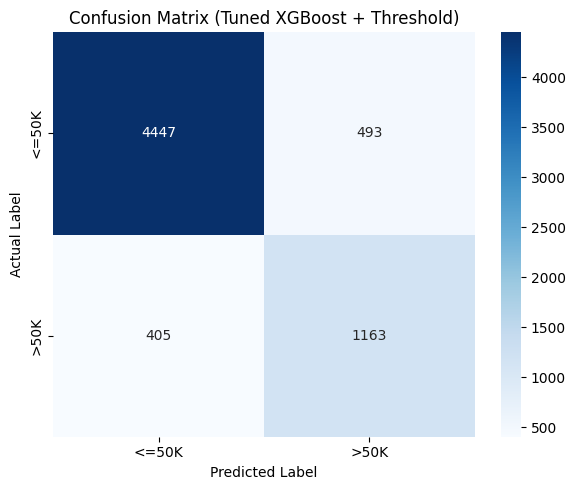

In [44]:
cm = confusion_matrix(y_test_enc, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['<=50K', '>50K'],
    yticklabels=['<=50K', '>50K'])
plt.title("Confusion Matrix (Tuned XGBoost + Threshold)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

The confusion matrix shows strong performance on the <=50K class and good recall for the >50K class. The model slightly favors predicting high-income individuals, which improves recall while maintaining reasonable precision.

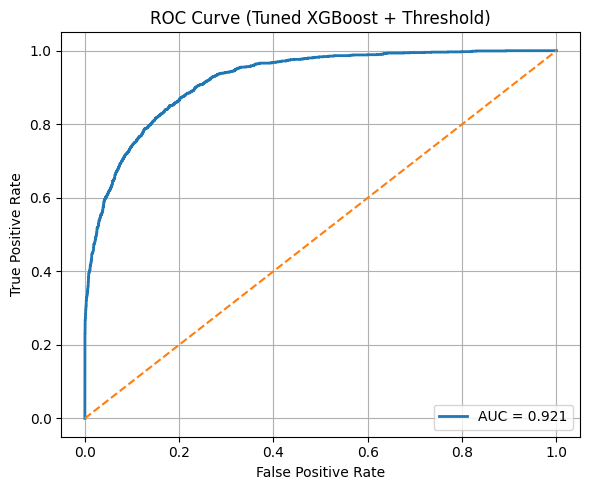

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test_enc, y_proba)
roc_auc = roc_auc_score(y_test_enc, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve (Tuned XGBoost + Threshold)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

The ROC-AUC score of 0.92 indicates excellent class separability, meaning the model can effectively distinguish between income groups across all thresholds.

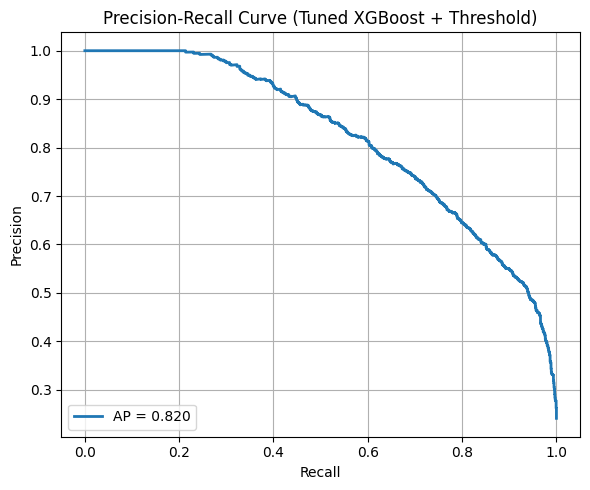

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
precision, recall, _ = precision_recall_curve(y_test_enc, y_proba)
ap_score = average_precision_score(y_test_enc, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, linewidth=2, label=f"AP = {ap_score:.3f}")
plt.title("Precision-Recall Curve (Tuned XGBoost + Threshold)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Model Interpretation 

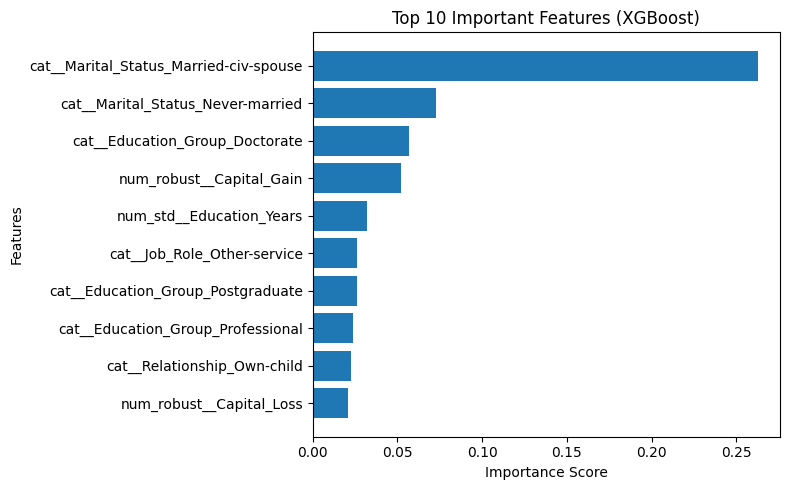

In [48]:
plt.figure(figsize=(8, 5))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Marital status is the strongest predictor, with married individuals more likely to have higher income. Education level and capital gain also play a significant role, indicating that higher qualifications and financial investments are key drivers of income. Overall, the model highlights strong socio-economic factors influencing salary.

**Actionable Business Insights**

- Married individuals are the strongest high-income segment → prioritize them for premium financial products, loans, and investment services.

- Customers with capital gains are highly likely to have higher income → target them for wealth management, trading platforms, and advanced financial products.

- Highly educated individuals (more education years) show strong earning potential → useful for early targeting of high-value customers.

- Managerial and professional job roles (e.g., Exec-managerial) indicate higher income → ideal segment for premium services and credit offerings.

- Household and relationship status can be used for customer segmentation → different financial products can be tailored based on family structure.

- Lower-income segments (e.g., unmarried, service roles) can be targeted with skill development, career growth programs, or entry-level financial products.

- The model can be used for customer prioritization → helping businesses focus on high-value customers efficiently.

- Marketing campaigns can be optimized by focusing on socio-economic indicators rather than only demographic or geographic factors.

**9. Deployment Readiness**

In [49]:
import joblib

joblib.dump(best_model, "xgboost_salary_pipeline.pkl")
joblib.dump(best_threshold, "xgboost_threshold_0_40.pkl")

['xgboost_threshold_0_40.pkl']

In [56]:
import joblib

model = joblib.load("xgboost_salary_pipeline.pkl")
threshold = joblib.load("xgboost_threshold_0_40.pkl")

print("Loaded successfully ")

Loaded successfully 


In [54]:
import sys
import sklearn
import xgboost
import pandas
import numpy
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.3.2
xgboost: 1.7.6
pandas: 2.3.3
numpy: 1.26.4
joblib: 1.5.3
Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.3.2
xgboost: 1.7.6
pandas: 2.3.3
numpy: 1.26.4
joblib: 1.5.3
